<a href="https://colab.research.google.com/github/adamzsl/unsupervised-learning/blob/main/SRResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, IterableDataset
from torch.amp import autocast, GradScaler

from torchvision import transforms
from torchvision.transforms import ToTensor, Resize
from PIL import Image

from datasets import load_dataset
import matplotlib.pyplot as plt
import random
from torchvision.models import vgg19


In [2]:
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = vgg19(weights="IMAGENET1K_V1").features[:35]
        self.vgg = vgg.eval()
        for param in self.vgg.parameters():
            param.requires_grad = False

    def forward(self, sr, hr):
        # VGG oczekuje zakresu [0,1] i 3 kanałów — OK
        return torch.mean((self.vgg(sr) - self.vgg(hr)) ** 2)


In [3]:
class SplitIterableDataset(IterableDataset):
    def __init__(self, dataset, split="train"):
        assert split in ["train", "val"]
        self.dataset = dataset
        self.split = split

    def __iter__(self):
        for i, sample in enumerate(self.dataset):
            if self.split == "train" and i % 10 < 8:
                yield sample
            elif self.split == "val" and i % 10 == 8:
                yield sample


In [4]:
class WikiArtSRPatchDataset(IterableDataset):
    def __init__(self, hf_stream, hr_image_size, hr_patch_size, scale=2):
        self.dataset = hf_stream
        self.hr_image_size = hr_image_size
        self.hr_patch_size = hr_patch_size
        self.lr_patch_size = hr_patch_size // scale

        self.to_tensor = transforms.ToTensor()
        self.resize_hr = transforms.Resize(
            (hr_image_size, hr_image_size),
            interpolation=Image.BICUBIC
        )

    def __iter__(self):
        for sample in self.dataset:
            img = sample["image"]
            if not isinstance(img, Image.Image):
                img = Image.fromarray(img)

            img = self.resize_hr(img)

            x = random.randint(0, self.hr_image_size - self.hr_patch_size)
            y = random.randint(0, self.hr_image_size - self.hr_patch_size)

            hr_patch = img.crop((x, y, x + self.hr_patch_size, y + self.hr_patch_size))
            lr_patch = hr_patch.resize(
                (self.lr_patch_size, self.lr_patch_size),
                Image.BICUBIC
            )

            yield self.to_tensor(lr_patch), self.to_tensor(hr_patch)


In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)


class UpsampleBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels * 4, 3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )

    def forward(self, x):
        return self.block(x)


class SRResNet(nn.Module):
    def __init__(self, num_blocks=8):
        super().__init__()

        self.entry = nn.Sequential(
            nn.Conv2d(3, 64, 9, padding=4),
            nn.PReLU()
        )

        self.residuals = nn.Sequential(
            *[ResidualBlock(64) for _ in range(num_blocks)]
        )

        self.mid = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1)
        )

        self.upsample = UpsampleBlock(64)
        self.exit = nn.Conv2d(64, 3, 9, padding=4)

    def forward(self, x):
        x1 = self.entry(x)
        x2 = self.mid(self.residuals(x1))
        x = x1 + x2
        x = self.upsample(x)
        return self.exit(x)


In [6]:
def psnr(sr, hr):
    mse = torch.mean((sr - hr) ** 2)
    return 20 * torch.log10(1.0 / torch.sqrt(mse + 1e-8))


def train_sr(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    lambda_vgg=0.0
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    l1_loss = nn.L1Loss()

    # perceptual loss tylko jeśli lambda > 0
    if lambda_vgg > 0:
        perceptual_loss = VGGPerceptualLoss().to(device)
    else:
        perceptual_loss = None

    scaler = GradScaler(enabled=(device == "cuda"))

    for epoch in range(epochs):
        model.train()
        loss_sum = 0.0
        steps = 0

        for lr_img, hr_img in train_loader:
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            optimizer.zero_grad()

            with autocast(device_type="cuda", enabled=(device == "cuda")):
                sr = model(lr_img)

                loss_l1 = l1_loss(sr, hr_img)

                if perceptual_loss is not None:
                    loss_vgg = perceptual_loss(sr, hr_img)
                    loss = loss_l1 + lambda_vgg * loss_vgg
                else:
                    loss = loss_l1

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            loss_sum += loss_l1.item()   # raportujemy L1 (czytelniejsze)
            steps += 1

            if steps == 100:
                break

        # ===== WALIDACJA =====
        model.eval()
        psnr_sum = 0.0
        vsteps = 0

        with torch.no_grad():
            for lr_img, hr_img in val_loader:
                lr_img = lr_img.to(device)
                hr_img = hr_img.to(device)

                sr = model(lr_img)
                psnr_sum += psnr(sr, hr_img).item()
                vsteps += 1

                if vsteps == 20:
                    break

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"L1: {loss_sum/steps:.4f} | "
            f"VAL PSNR: {psnr_sum/vsteps:.2f} dB"
        )


In [7]:
hf_stream = load_dataset(
    "huggan/wikiart",
    split="train",
    streaming=True
)

train_stream = SplitIterableDataset(hf_stream, "train")
val_stream   = SplitIterableDataset(hf_stream, "val")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

In [8]:
train_ds_1 = WikiArtSRPatchDataset(train_stream, 256, 128)
val_ds_1   = WikiArtSRPatchDataset(val_stream,   256, 128)

train_loader_1 = DataLoader(train_ds_1, batch_size=8, num_workers=2)
val_loader_1   = DataLoader(val_ds_1,   batch_size=8, num_workers=2)

model_stage1 = SRResNet()

train_sr(
    model_stage1,
    train_loader_1,
    val_loader_1,
    epochs=6, #od 5 do 10 można dać
    lr=1e-4
)


Epoch 1/8 | L1: 0.1104 | VAL PSNR: 19.78 dB
Epoch 2/8 | L1: 0.0599 | VAL PSNR: 20.71 dB
Epoch 3/8 | L1: 0.0487 | VAL PSNR: 22.81 dB
Epoch 4/8 | L1: 0.0450 | VAL PSNR: 23.61 dB
Epoch 5/8 | L1: 0.0414 | VAL PSNR: 24.10 dB


'('Connection broken: IncompleteRead(259792612 bytes read, 262191123 more expected)', IncompleteRead(259792612 bytes read, 262191123 more expected))' thrown while requesting GET https://huggingface.co/datasets/huggan/wikiart/resolve/d559852d2b232e0fcf195e775866964f0564f2b5/data/train-00000-of-00072.parquet
Retrying in 1s [Retry 1/5].


Epoch 6/8 | L1: 0.0378 | VAL PSNR: 24.59 dB
Epoch 7/8 | L1: 0.0374 | VAL PSNR: 24.44 dB
Epoch 8/8 | L1: 0.0372 | VAL PSNR: 24.85 dB


In [9]:
# ===== DEFINICJA LOADERÓW ETAP 2 (BEZPIECZNA) =====

train_ds_2 = WikiArtSRPatchDataset(train_stream, 512, 256)
val_ds_2   = WikiArtSRPatchDataset(val_stream,   512, 256)

train_loader_2 = DataLoader(train_ds_2, batch_size=8, num_workers=2)
val_loader_2   = DataLoader(val_ds_2,   batch_size=8, num_workers=2)


In [10]:
FINAL_LAMBDA = 0.01   # <<< TU USTALASZ FINALNĄ LAMBDĘ

model_stage2 = SRResNet()
model_stage2.load_state_dict(model_stage1.state_dict())

train_sr(
    model_stage2,
    train_loader_2,
    val_loader_2,
    epochs=4,
    lr=5e-5,
    lambda_vgg=FINAL_LAMBDA
)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 93.7MB/s]


Epoch 1/5 | L1: 0.0325 | VAL PSNR: 26.05 dB


'HTTPSConnectionPool(host='us.gcp.cdn.hf.co', port=443): Read timed out.' thrown while requesting GET https://huggingface.co/datasets/huggan/wikiart/resolve/d559852d2b232e0fcf195e775866964f0564f2b5/data/train-00000-of-00072.parquet
Retrying in 1s [Retry 1/5].


Epoch 2/5 | L1: 0.0305 | VAL PSNR: 26.41 dB
Epoch 3/5 | L1: 0.0296 | VAL PSNR: 26.25 dB
Epoch 4/5 | L1: 0.0290 | VAL PSNR: 26.65 dB
Epoch 5/5 | L1: 0.0289 | VAL PSNR: 26.64 dB


In [11]:
import torch.nn.functional as F

def sr_full_image(model, lr_image, scale=2, patch_size=64, overlap=16):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device).eval()

    _, H, W = lr_image.shape
    stride = patch_size - overlap

    # 🔧 OBLICZ PADDING
    pad_h = (stride - (H - patch_size) % stride) % stride
    pad_w = (stride - (W - patch_size) % stride) % stride

    lr_image = lr_image.unsqueeze(0)
    lr_image = F.pad(
        lr_image,
        (0, pad_w, 0, pad_h),
        mode="reflect"
    ).squeeze(0)

    _, H_pad, W_pad = lr_image.shape
    sr_H, sr_W = H_pad * scale, W_pad * scale

    output = torch.zeros(3, sr_H, sr_W, device=device)
    weight = torch.zeros(3, sr_H, sr_W, device=device)

    lr_image = lr_image.to(device)

    for y in range(0, H_pad - patch_size + 1, stride):
        for x in range(0, W_pad - patch_size + 1, stride):
            lr_patch = lr_image[:, y:y+patch_size, x:x+patch_size].unsqueeze(0)

            with torch.no_grad():
                sr_patch = model(lr_patch).squeeze(0)

            y_sr, x_sr = y * scale, x * scale
            output[:, y_sr:y_sr+patch_size*scale, x_sr:x_sr+patch_size*scale] += sr_patch
            weight[:, y_sr:y_sr+patch_size*scale, x_sr:x_sr+patch_size*scale] += 1

    sr = (output / weight).clamp(0, 1)

    # 🔧 USUŃ PADDING
    return sr[:, :H*scale, :W*scale].cpu()


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Test image size: (1629, 1382)
Final SR resolution: torch.Size([3, 1380, 1628])


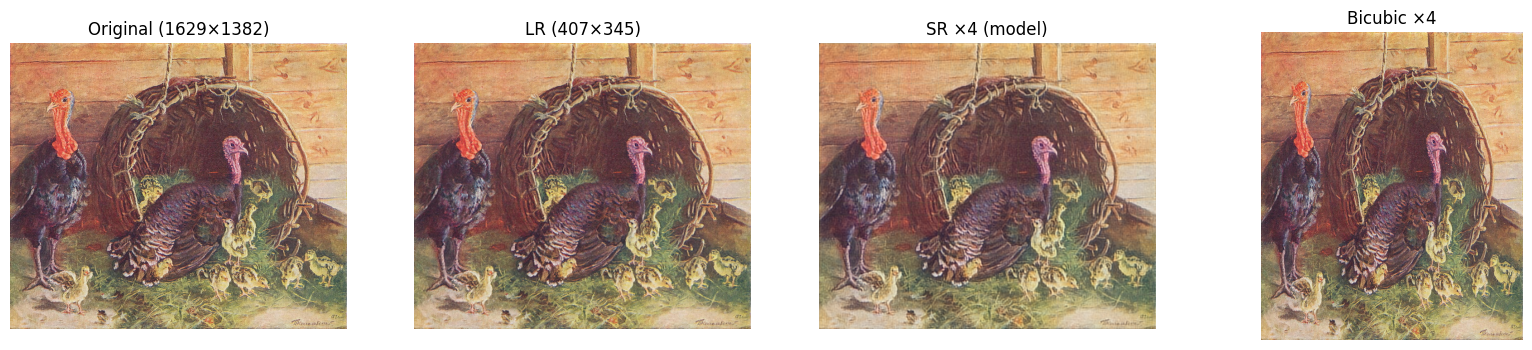

In [12]:
# ===== TEST SUPER-RESOLUTION ×4 NA LOSOWYM OBRAZIE Z WIKIART =====

from datasets import load_dataset
import random
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision.transforms import ToTensor, Resize
import matplotlib.pyplot as plt

# ===== FUNKCJA DO WYŚWIETLANIA =====
def show(img, title):
    plt.imshow(img.permute(1,2,0))
    plt.title(title)
    plt.axis("off")

# ===== 1️⃣ LOSOWY OBRAZ Z WIKIART (PEŁNY OBRAZ) =====
wikiart_full = load_dataset(
    "huggan/wikiart",
    split="train",
    streaming=True
)

sample = None
for s in wikiart_full:
    if random.random() < 0.001:  # losowanie bez znajomości długości
        sample = s
        break

img = sample["image"]
if not isinstance(img, Image.Image):
    img = Image.fromarray(img)

print("Test image size:", img.size)

# ===== 2️⃣ SYMULACJA NISKIEJ ROZDZIELCZOŚCI (×4) =====
# zachowujemy proporcje obrazu
lr_img = Resize(
    (img.size[1] // 4, img.size[0] // 4),
    interpolation=Image.BICUBIC
)(img)

lr_tensor = ToTensor()(lr_img)

# ===== 3️⃣ ETAP 1: ×2 (128→256 lub proporcjonalnie) =====
sr_x2 = sr_full_image(
    model_stage1,
    lr_tensor,
    patch_size=64,
    overlap=16
)

# ===== 4️⃣ ETAP 2: ×4 (256→512 lub proporcjonalnie) =====
sr_x4 = sr_full_image(
    model_stage2,   # FINALNY MODEL z λ = 0.01
    sr_x2,
    patch_size=128,
    overlap=32
)

print("Final SR resolution:", sr_x4.shape)

# ===== 5️⃣ WIZUALIZACJA =====
plt.figure(figsize=(20,4))

plt.subplot(1,4,1)
show(ToTensor()(img), f"Original ({img.size[0]}×{img.size[1]})")

plt.subplot(1,4,2)
show(lr_tensor, f"LR ({lr_tensor.shape[2]}×{lr_tensor.shape[1]})")

plt.subplot(1,4,3)
show(sr_x4, "SR ×4 (model)")

plt.subplot(1,4,4)
show(ToTensor()(img.resize(sr_x4.shape[1:])), "Bicubic ×4")

plt.show()
